# Semana 11 — AED com dados simples: desempenho de estudantes

Este notebook trabalha os conteúdos das aulas de **Análise Exploratória de Dados (AED)** usando uma NOVA base 

## Objetivo da aula

O foco aqui não é apenas calcular com Python. O foco é **interpretar o que os resultados querem dizer**.

## 1. Preparação do ambiente

In [2]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuração para exibir mais colunas
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

## 2. Carregando os dados

Coloque o arquivo `StudentsPerformance.csv` na mesma pasta deste notebook.

In [3]:
# Leitura do CSV baixado manualmente do Kaggle
arquivo = "StudentsPerformance.csv"
df = pd.read_csv(arquivo)

# Visualizar as primeiras linhas
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Renomeando colunas para português

Para facilitar a aula, vamos traduzir os nomes das colunas.

In [4]:
df = df.rename(columns={
    'gender': 'genero',
    'race/ethnicity': 'grupo_etnico',
    'parental level of education': 'escolaridade_pais',
    'lunch': 'tipo_almoco',
    'test preparation course': 'curso_preparatorio',
    'math score': 'nota_matematica',
    'reading score': 'nota_leitura',
    'writing score': 'nota_escrita'
})

df.head()

,genero,grupo_etnico,escolaridade_pais,tipo_almoco,curso_preparatorio,nota_matematica,nota_leitura,nota_escrita
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Nível fácil — conhecer os dados

Nesta primeira parte, o objetivo é entender a estrutura da base.

## Exercício 1 — Tamanho da base

Execute o código abaixo e responda:

1. Quantas linhas existem na base?
2. Quantas colunas existem?
3. Cada linha representa o quê?

In [5]:
df.shape

(1000, 8)

**Resposta do aluno:**

1. 1000 linhas
2. 8 colunas
3. Cada linha representa 1 aluno


## Exercício 2 — Tipos das variáveis

Execute o código abaixo e responda:

1. Quais colunas são numéricas?
2. Quais colunas são categóricas/texto?
3. Por que isso é importante antes de fazer gráficos ou cálculos?

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   genero              1000 non-null   str  
 1   grupo_etnico        1000 non-null   str  
 2   escolaridade_pais   1000 non-null   str  
 3   tipo_almoco         1000 non-null   str  
 4   curso_preparatorio  1000 non-null   str  
 5   nota_matematica     1000 non-null   int64
 6   nota_leitura        1000 non-null   int64
 7   nota_escrita        1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


**Resposta do aluno:**

1. nota_matematica, nota_leitura e nota_escrita.
2. genero, grupo_etnico, escolaridade_pais, tipo_almoco e curso_preparatorio.
3. Para definir quais tipos de análises podemos fazer com cada coluna.

## Exercício 3 — Primeira leitura dos dados

Observe as primeiras linhas da base e responda:

1. As colunas parecem fáceis de entender?
2. O que as notas representam?
3. Que perguntas de negócio ou de análise poderiam ser feitas com essa base?

In [7]:
df.head(10)

,genero,grupo_etnico,escolaridade_pais,tipo_almoco,curso_preparatorio,nota_matematica,nota_leitura,nota_escrita
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


**Resposta do aluno:**

1. Sim
2. As notas representam que os alunos que tiveram almoço gratis/reduzido tiveram as notas mais baixas.
3. Qual o fator principal para indicar as notas baixas?
   Qual o nível de influência da escolaridade dos pais nas notas dos alunos?

## Exercício 4 — Valores ausentes e duplicados

Execute os códigos e responda:

1. Existem valores ausentes?
2. Existem linhas duplicadas?
3. Se existissem valores ausentes em notas, seria correto preencher automaticamente com a média? Justifique.

In [8]:
df.isnull().sum()

genero                0
grupo_etnico          0
escolaridade_pais     0
tipo_almoco           0
curso_preparatorio    0
nota_matematica       0
nota_leitura          0
nota_escrita          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

**Resposta do aluno:**

1. Não
2. Não
3.

# Nível médio — estatística descritiva e interpretação

Agora vamos analisar média, mediana, desvio padrão, quartis e diferenças entre grupos.

## Exercício 5 — Estatísticas gerais das notas

Execute o código e responda:

1. Qual nota tem maior média?
2. Qual nota tem menor média?
3. A média e a mediana estão próximas? O que isso sugere?
4. Alguma disciplina parece ter maior dispersão?

In [10]:
df[['nota_matematica', 'nota_leitura', 'nota_escrita']].describe()

,nota_matematica,nota_leitura,nota_escrita
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Resposta do aluno:**

1. Leitura
2. Leitura
3. Sim.
4. Sim. Matematica

## Exercício 6 — Média x mediana

Execute o código e responda:

1. Em qual nota a média e a mediana são mais diferentes?
2. O que uma diferença grande entre média e mediana poderia indicar?
3. Neste caso, você usaria média ou mediana para representar melhor o desempenho geral? Justifique.

In [11]:
resumo_notas = pd.DataFrame({
    'media': df[['nota_matematica', 'nota_leitura', 'nota_escrita']].mean(),
    'mediana': df[['nota_matematica', 'nota_leitura', 'nota_escrita']].median(),
    'desvio_padrao': df[['nota_matematica', 'nota_leitura', 'nota_escrita']].std()
})

resumo_notas

,media,mediana,desvio_padrao
nota_matematica,66.089,66.0,15.163080
nota_leitura,69.169,70.0,14.600192
nota_escrita,68.054,69.0,15.195657


**Resposta do aluno:**

1. Leitura
2. Que podem existir outliers
3. Media

## Exercício 7 — Quartis e IQR

Execute o código e responda:

1. O que representa o Q1?
2. O que representa o Q3?
3. O que o IQR mostra sobre as notas?
4. Em qual disciplina os 50% centrais parecem mais espalhados?

In [12]:
quartis = df[['nota_matematica', 'nota_leitura', 'nota_escrita']].quantile([0.25, 0.5, 0.75])
quartis

,nota_matematica,nota_leitura,nota_escrita
0.25,57.0,59.0,57.75
0.50,66.0,70.0,69.00
0.75,77.0,79.0,79.00


In [13]:
iqr = df[['nota_matematica', 'nota_leitura', 'nota_escrita']].quantile(0.75) - df[['nota_matematica', 'nota_leitura', 'nota_escrita']].quantile(0.25)
iqr

nota_matematica    20.00
nota_leitura       20.00
nota_escrita       21.25
dtype: float64

**Resposta do aluno:**

1. 25%
2. 75%
3. Que a nota de escrita tem o maior IQR
4. Escrita

## Exercício 8 — Comparando grupos: curso preparatório

Execute o código e responda:

1. Quem fez curso preparatório teve médias maiores?
2. A diferença parece pequena ou relevante?
3. Podemos afirmar que o curso preparatório causou notas maiores? Por quê?

In [14]:
df.groupby('curso_preparatorio')[['nota_matematica', 'nota_leitura', 'nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
curso_preparatorio,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


**Resposta do aluno:**

1. Sim
2. Relevante
3. Sim. Porque os alunos com curso preparatório tiveram médias melhores.

## Exercício 9 — Comparando grupos: tipo de almoço

Execute o código e responda:

1. Existe diferença entre estudantes com almoço padrão e almoço reduzido/gratuito?
2. Em quais notas a diferença aparece mais?
3. Que hipótese essa comparação pode gerar?

In [15]:
df.groupby('tipo_almoco')[['nota_matematica', 'nota_leitura', 'nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
tipo_almoco,,,
free/reduced,58.92,64.65,63.02
standard,70.03,71.65,70.82


**Resposta do aluno:**

1. Sim
2. Matemática
3. Que a refeição correta reflete diretamente no desempenhon do aluno

# Nível difícil — visualização, outliers e relatório interpretativo

Nesta parte, o aluno precisa interpretar padrões, anomalias e possíveis decisões de análise.

## Exercício 10 — Histograma das notas

Execute os histogramas e responda:

1. As notas parecem simétricas ou assimétricas?
2. Existe concentração em alguma faixa de nota?
3. Há indícios de notas muito baixas ou muito altas?
4. A média parece representar bem essas distribuições?

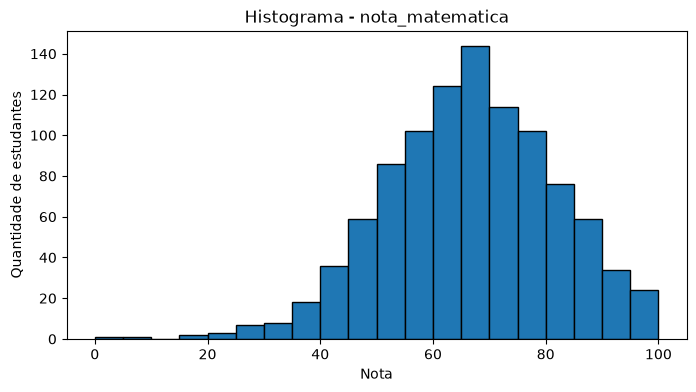

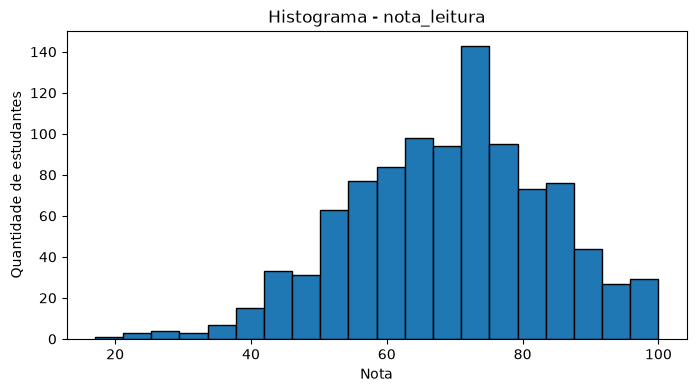

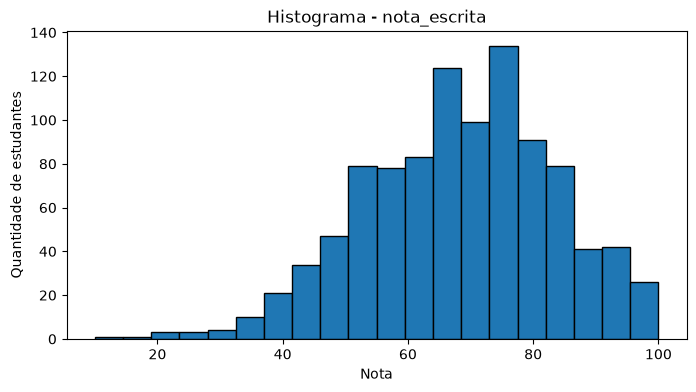

In [16]:
for coluna in ['nota_matematica', 'nota_leitura', 'nota_escrita']:
    plt.figure(figsize=(8, 4))
    plt.hist(df[coluna], bins=20, edgecolor='black')
    plt.title(f'Histograma - {coluna}')
    plt.xlabel('Nota')
    plt.ylabel('Quantidade de estudantes')
    plt.show()

**Resposta do aluno:**

1. Simétrica
2. Entre 55 e 80
3. indícios de notas muito baixas
4. Sim

## Exercício 11 — Boxplot e possíveis outliers

Execute os boxplots e responda:

1. Existem pontos muito abaixo do padrão?
2. Esses pontos devem ser removidos automaticamente?
3. Que tipo de investigação deveria ser feita antes de remover algum valor?

C:\Users\robso\AppData\Local\Temp\ipykernel_9656\4072998540.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[coluna], vert=False)


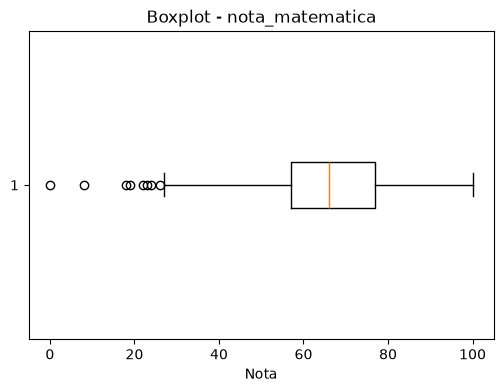

C:\Users\robso\AppData\Local\Temp\ipykernel_9656\4072998540.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[coluna], vert=False)


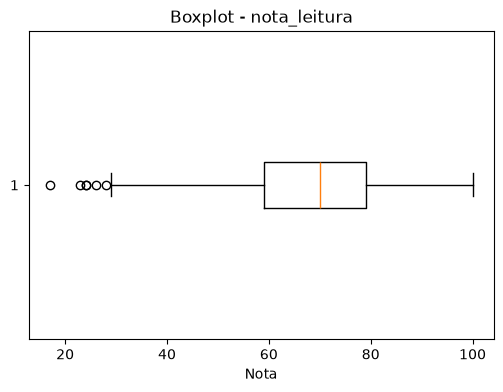

C:\Users\robso\AppData\Local\Temp\ipykernel_9656\4072998540.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[coluna], vert=False)


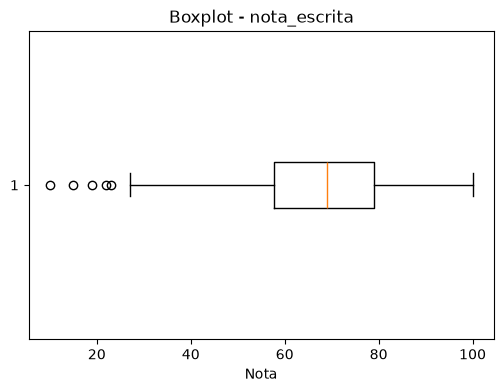

In [17]:
for coluna in ['nota_matematica', 'nota_leitura', 'nota_escrita']:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[coluna], vert=False)
    plt.title(f'Boxplot - {coluna}')
    plt.xlabel('Nota')
    plt.show()

**Resposta do aluno:**

1. Sim
2. Não
3. Verificar se há algum outro tipo de dado que justifique os valores abaixo do padrão, como por exemplo uma falta em uma prova

## Exercício 12 — Identificando outliers pelo IQR

Execute o código e responda:

1. Quais valores são considerados possíveis outliers?
2. Eles parecem erro de digitação ou casos reais?
3. Por que uma nota baixa pode ser importante para a análise?

In [18]:
coluna = 'nota_matematica'

q1 = df[coluna].quantile(0.25)
q3 = df[coluna].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)
print('Limite inferior:', limite_inferior)
print('Limite superior:', limite_superior)

outliers_matematica = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
outliers_matematica[[coluna, 'genero', 'tipo_almoco', 'curso_preparatorio', 'escolaridade_pais']]

Q1: 57.0
Q3: 77.0
IQR: 20.0
Limite inferior: 27.0
Limite superior: 107.0


,nota_matematica,genero,tipo_almoco,curso_preparatorio,escolaridade_pais
17,18,female,free/reduced,none,some high school
59,0,female,free/reduced,none,some high school
145,22,female,free/reduced,none,some college
338,24,female,free/reduced,none,some high school
466,26,female,free/reduced,none,associate's degree
787,19,female,standard,none,some college
842,23,female,free/reduced,completed,high school
980,8,female,free/reduced,none,high school


**Resposta do aluno:**

1. 0,8,18 e 19
2. Casos reais
3. Porque através do relacionamento dela com outros dados, podemos identificar padrões

## Exercício 13 — Gráfico comparativo por curso preparatório

Execute o gráfico e responda:

1. O curso preparatório parece estar associado a notas maiores?
2. A diferença é parecida em matemática, leitura e escrita?
3. Que cuidado devemos ter ao interpretar esse resultado?

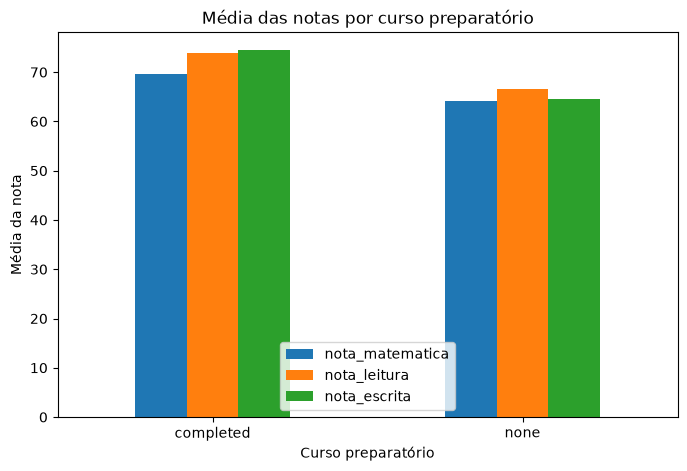

In [19]:
medias_curso = df.groupby('curso_preparatorio')[['nota_matematica', 'nota_leitura', 'nota_escrita']].mean()

medias_curso.plot(kind='bar', figsize=(8, 5))
plt.title('Média das notas por curso preparatório')
plt.xlabel('Curso preparatório')
plt.ylabel('Média da nota')
plt.xticks(rotation=0)
plt.show()

**Resposta do aluno:**

1. Sim
2. Sim
3. Não tratar esse somente como o fator determinante sem analisar outras variaveis

### AULA 2

## Exercício 14 — Relatório automatizado com ydata-profiling

Este trecho é opcional. Se a biblioteca não estiver instalada, execute:

`pip install ydata-profiling`

Depois rode o código abaixo.

Responda:

1. O relatório ajuda a encontrar padrões mais rápido?
2. Quais alertas ou informações chamaram atenção?
3. O relatório substitui a interpretação do analista? Justifique.

In [23]:
%pip install sweetviz

Note: you may need to restart the kernel to use updated packages.


In [27]:
# Caso necessário, instale antes:
# !pip install sweetviz

import sweetviz as sv

analysis = sv.analyze(df)
analysis.show_html('relatorio_aed_estudantes.html', open_browser=False)

Feature: genero                              |█         | [ 11%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: grupo_etnico                        |██▏       | [ 22%]   00:00 -> (00:03 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: escolaridade_pais                   |███▎      | [ 33%]   00:01 -> (00:03 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: tipo_al

Report relatorio_aed_estudantes.html was generated.


**Resposta do aluno:**

Escreva aqui sua interpretação.

### AULA 3

## Exercício 15 — Relatório automatizado com Sweetviz

Este trecho é opcional. Se a biblioteca não estiver instalada, execute:

`pip install sweetviz`

Depois rode o código abaixo.

Responda:

1. O Sweetviz facilita a comparação entre variáveis?
2. Que variável parece mais interessante para investigar?
3. Que risco existe em aceitar automaticamente tudo que o relatório mostra?

In [28]:
# Caso necessário, instale antes:
# !pip install sweetviz

import locale
import sweetviz as sv

# Configura para português
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
except:
    try:
        locale.setlocale(locale.LC_ALL, 'pt_BR')
    except:
        pass

report = sv.analyze(df)
report.show_html('relatorio_sweetviz_estudantes.html', open_browser=False)

Feature: genero                              |█         | [ 11%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: grupo_etnico                        |██▏       | [ 22%]   00:00 -> (00:02 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: escolaridade_pais                   |███▎      | [ 33%]   00:01 -> (00:03 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: tipo_al

Report relatorio_sweetviz_estudantes.html was generated.


**Resposta do aluno:**

Escreva aqui sua interpretação.

# Desafio final — mini relatório de AED

Com base em tudo que você analisou, escreva um mini relatório com:

1. O que a base representa.
2. Quais variáveis foram analisadas.
3. Quais padrões apareceram.
4. Se existem possíveis outliers.
5. Se há diferenças entre grupos.
6. Quais cuidados você teria antes de tomar decisões.
7. Uma hipótese que poderia ser investigada em uma próxima análise.

**Resposta do aluno:**

Escreva aqui seu mini relatório.